# Performance Analytics of Mutual Funds

## Objective

The objective of this notebook is to evaluate the performance of mutual funds using various financial metrics. The analysis includes:

- Daily Return
- CAGR (1-Year, 3-Year, 5-Year)
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison

## Step 1: Import Required Libraries

The required Python libraries are imported for data analysis, statistical calculations, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import linregress

plt.style.use("ggplot")

## Step 2: Load NAV History Dataset

The cleaned NAV history dataset is loaded into a pandas DataFrame. This dataset contains the historical NAV values for all mutual fund schemes and serves as the primary data source for the performance analysis.

In [2]:
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

## Step 3: Explore the Dataset

The dataset structure is examined to verify the available columns, data types, and sample records before performing calculations.

In [3]:
nav.columns

Index(['date', 'amfi_code', 'nav'], dtype='str')

In [4]:
nav.head()

,date,amfi_code,nav
0,2022-01-03,100016,520.4608
1,2022-01-04,100016,515.0971
2,2022-01-05,100016,521.7239
3,2022-01-06,100016,515.7880
4,2022-01-07,100016,515.1639


## Step 4: Data Preparation

The date column is converted into datetime format, and the dataset is sorted by AMFI code and date. Sorting ensures that daily returns are calculated in chronological order for each mutual fund.

In [5]:

nav["date"] = pd.to_datetime(nav["date"])


nav = nav.sort_values(["amfi_code", "date"])


nav.head()

,date,amfi_code,nav
0,2022-01-03,100016,520.4608
1,2022-01-04,100016,515.0971
2,2022-01-05,100016,521.7239
3,2022-01-06,100016,515.7880
4,2022-01-07,100016,515.1639


## Step 5: Calculate Daily Returns

Daily returns are computed using the percentage change in NAV for each mutual fund.

**Formula**

Daily Return = (Current NAV / Previous NAV) − 1

The first observation for each fund does not have a previous NAV value; therefore, its daily return is recorded as NaN.

In [6]:

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [7]:
nav.head(10)

,date,amfi_code,nav,daily_return
0,2022-01-03,100016,520.4608,NaN
1,2022-01-04,100016,515.0971,-0.010306
2,2022-01-05,100016,521.7239,0.012865
3,2022-01-06,100016,515.7880,-0.011377
4,2022-01-07,100016,515.1639,-0.001210
5,2022-01-08,100016,515.1639,0.000000
6,2022-01-09,100016,515.1639,0.000000
7,2022-01-10,100016,510.7136,-0.008639
8,2022-01-11,100016,513.5542,0.005562
9,2022-01-12,100016,512.3195,-0.002404


## Step 6: Validate Daily Return Distribution

Descriptive statistics and a histogram are generated to evaluate the distribution of daily returns and identify any abnormal values.

In [8]:
nav["daily_return"].describe()

count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64

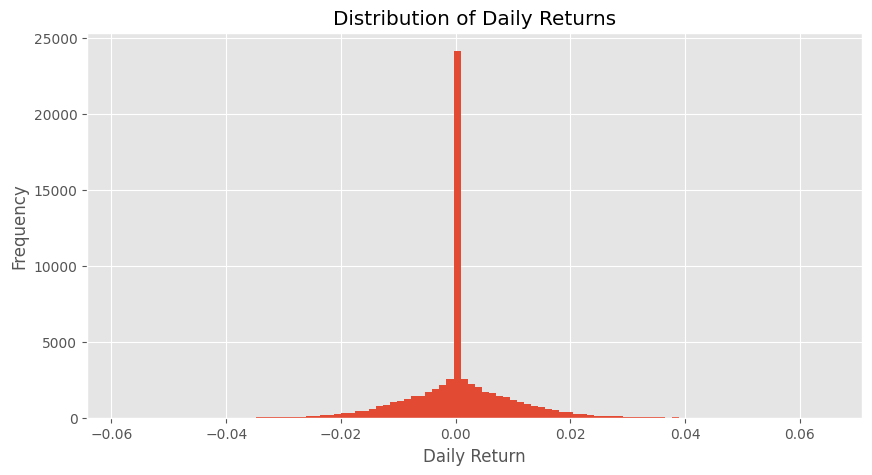

In [9]:
plt.figure(figsize=(10,5))
nav["daily_return"].dropna().hist(bins=100)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

## Step 7: Compound Annual Growth Rate (CAGR)

The Compound Annual Growth Rate (CAGR) measures the annualized growth of a mutual fund over a specified investment period. It smooths out returns over time and provides a consistent measure of long-term performance.

The analysis calculates CAGR for 1-year, 3-year periods for all available mutual funds.

In [10]:
def calculate_cagr(start_nav, end_nav, years):
    """
    Calculate Compound Annual Growth Rate (CAGR).
    """
    return (end_nav / start_nav) ** (1 / years) - 1

In [11]:
print("Start Date :", nav["date"].min())
print("End Date   :", nav["date"].max())
print("Unique Funds :", nav["amfi_code"].nunique())

Start Date : 2022-01-03 00:00:00
End Date   : 2026-05-29 00:00:00
Unique Funds : 40


In [12]:


def calculate_period_cagr(group, years):
    
    end_date = group["date"].max()
    start_date = end_date - pd.DateOffset(years=years)

    period_data = group[group["date"] >= start_date]

   
    if len(period_data) < 2:
        return np.nan

    start_nav = period_data.iloc[0]["nav"]
    end_nav = period_data.iloc[-1]["nav"]

    return (end_nav / start_nav) ** (1 / years) - 1

In [13]:
cagr_results = []

for fund, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    cagr_results.append({
        "amfi_code": fund,
        "CAGR_1Y": calculate_period_cagr(group, 1),
        "CAGR_3Y": calculate_period_cagr(group, 3),
        "CAGR_5Y": calculate_period_cagr(group, 5)
    })

cagr_df = pd.DataFrame(cagr_results)

In [14]:
cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [15]:
cagr_df = cagr_df.sort_values(
    by="CAGR_3Y",
    ascending=False
)

cagr_df.reset_index(drop=True, inplace=True)

cagr_df.head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,119094,0.222611,0.351118,0.244453
1,148567,0.203607,0.340009,0.267993
2,120504,0.130643,0.324874,0.202340
3,100033,0.532324,0.324425,0.260741
4,120505,0.296047,0.317775,0.283768
5,119551,0.604373,0.304565,0.223849
6,120843,0.266571,0.295828,0.267425
7,148569,0.397518,0.291789,0.276299
8,101206,0.479241,0.289677,0.204427
9,149324,0.651387,0.270004,0.279174


In [16]:
cagr_df.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

print("CAGR comparison table saved successfully!")

CAGR comparison table saved successfully!


## Step 8: Sharpe Ratio

The Sharpe Ratio measures the risk-adjusted return of a mutual fund. It compares the fund's excess return over the risk-free rate with its overall volatility.

A higher Sharpe Ratio indicates better returns for each unit of risk taken.

Assumptions:
- Risk-Free Rate (Rf) = 6.5% (0.065)
- Trading Days per Year = 252

In [17]:
RISK_FREE_RATE = 0.065
TRADING_DAYS = 252

In [18]:
sharpe_results = []

for fund, group in nav.groupby("amfi_code"):

  
    returns = group["daily_return"].dropna()

    
    if len(returns) < 2:
        continue

    annual_return = returns.mean() * TRADING_DAYS

    
    annual_volatility = returns.std() * np.sqrt(TRADING_DAYS)

 
    if annual_volatility == 0:
        sharpe = np.nan
    else:
        sharpe = (annual_return - RISK_FREE_RATE) / annual_volatility

    sharpe_results.append({
        "amfi_code": fund,
        "Annual_Return": annual_return,
        "Annual_Volatility": annual_volatility,
        "Sharpe_Ratio": sharpe
    })

In [19]:
sharpe_df = pd.DataFrame(sharpe_results)

In [20]:
sharpe_df = sharpe_df.sort_values(
    by="Sharpe_Ratio",
    ascending=False
)

sharpe_df.reset_index(drop=True, inplace=True)

sharpe_df["Sharpe_Rank"] = sharpe_df.index + 1

In [21]:
sharpe_df.head(10)

,amfi_code,Annual_Return,Annual_Volatility,Sharpe_Ratio,Sharpe_Rank
0,148567,0.193454,0.120250,1.068224,1
1,120843,0.194910,0.134543,0.965561,2
2,148569,0.202531,0.149645,0.919047,3
3,120505,0.209246,0.163311,0.883256,4
4,119551,0.165188,0.116365,0.860977,5
5,149323,0.190123,0.150229,0.832885,6
6,100033,0.194558,0.160291,0.808268,7
7,118632,0.155896,0.119781,0.758851,8
8,119094,0.184990,0.164246,0.730547,9
9,101206,0.153472,0.123321,0.717409,10


In [22]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio analysis saved successfully!")

Sharpe Ratio analysis saved successfully!


### Sharpe Ratio Ranking

The following chart displays the top 10 mutual funds ranked according to their Sharpe Ratio. Higher values indicate better risk-adjusted performance.

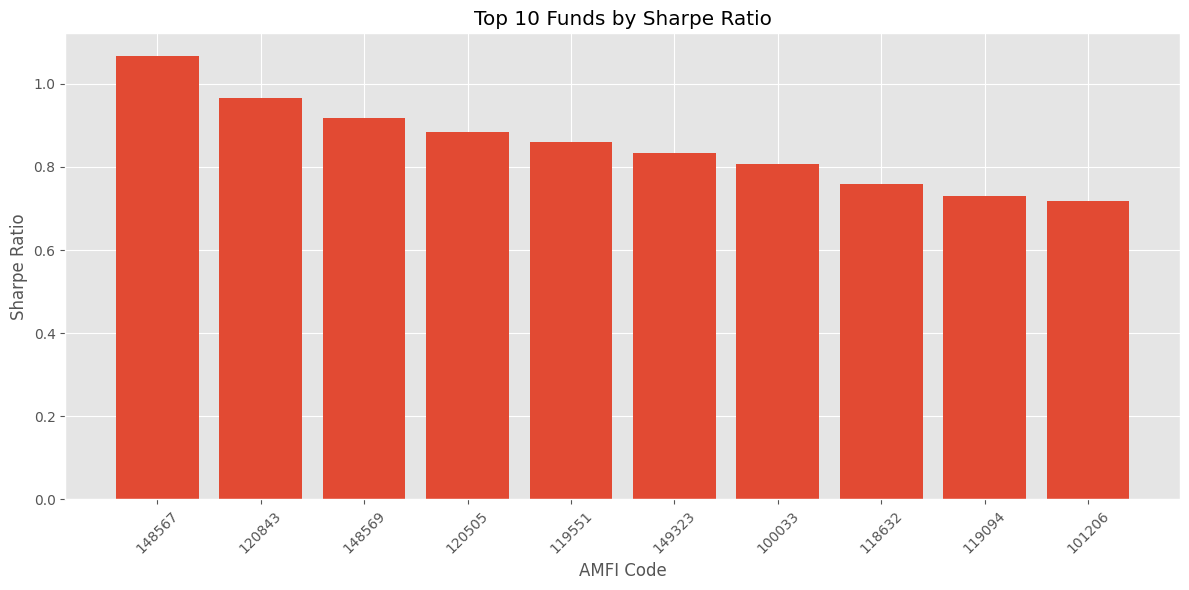

In [23]:
top10 = sharpe_df.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["Sharpe_Ratio"]
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sharpe Ratio")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Step 9: Sortino Ratio

The Sortino Ratio is a risk-adjusted performance metric that measures the excess return of a mutual fund relative to its downside risk. Unlike the Sharpe Ratio, it considers only negative return volatility, making it more suitable for evaluating investment performance where downside risk is the primary concern.

Assumptions:
- Risk-Free Rate (Rf) = 6.5% (0.065)
- Trading Days per Year = 252

In [24]:
sortino_results = []

for fund, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 2:
        continue

   
    annual_return = returns.mean() * TRADING_DAYS

    downside_returns = returns[returns < 0]

    if len(downside_returns) == 0:
        downside_std = np.nan
    else:
        downside_std = downside_returns.std() * np.sqrt(TRADING_DAYS)

    if pd.isna(downside_std) or downside_std == 0:
        sortino = np.nan
    else:
        sortino = (annual_return - RISK_FREE_RATE) / downside_std

    sortino_results.append({
        "amfi_code": fund,
        "Annual_Return": annual_return,
        "Downside_Deviation": downside_std,
        "Sortino_Ratio": sortino
    })

In [25]:
sortino_df = pd.DataFrame(sortino_results)

In [26]:
sortino_df = sortino_df.sort_values(
    by="Sortino_Ratio",
    ascending=False
)

sortino_df.reset_index(drop=True, inplace=True)

sortino_df["Sortino_Rank"] = sortino_df.index + 1

In [27]:
sortino_df.head(10)

,amfi_code,Annual_Return,Downside_Deviation,Sortino_Ratio,Sortino_Rank
0,148567,0.193454,0.086168,1.490739,1
1,120843,0.194910,0.087806,1.479503,2
2,148569,0.202531,0.101663,1.352815,3
3,119551,0.165188,0.077576,1.291483,4
4,120505,0.209246,0.112180,1.285843,5
5,149323,0.190123,0.107145,1.167793,6
6,100033,0.194558,0.113229,1.144216,7
7,118632,0.155896,0.082717,1.098880,8
8,119598,0.216398,0.141857,1.067256,9
9,120504,0.151899,0.081675,1.063964,10


In [28]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio saved successfully!")

Sortino Ratio saved successfully!


### Top 10 Funds by Sortino Ratio

The chart below displays the top-performing mutual funds ranked by their Sortino Ratio. Higher values indicate better downside risk-adjusted performance.

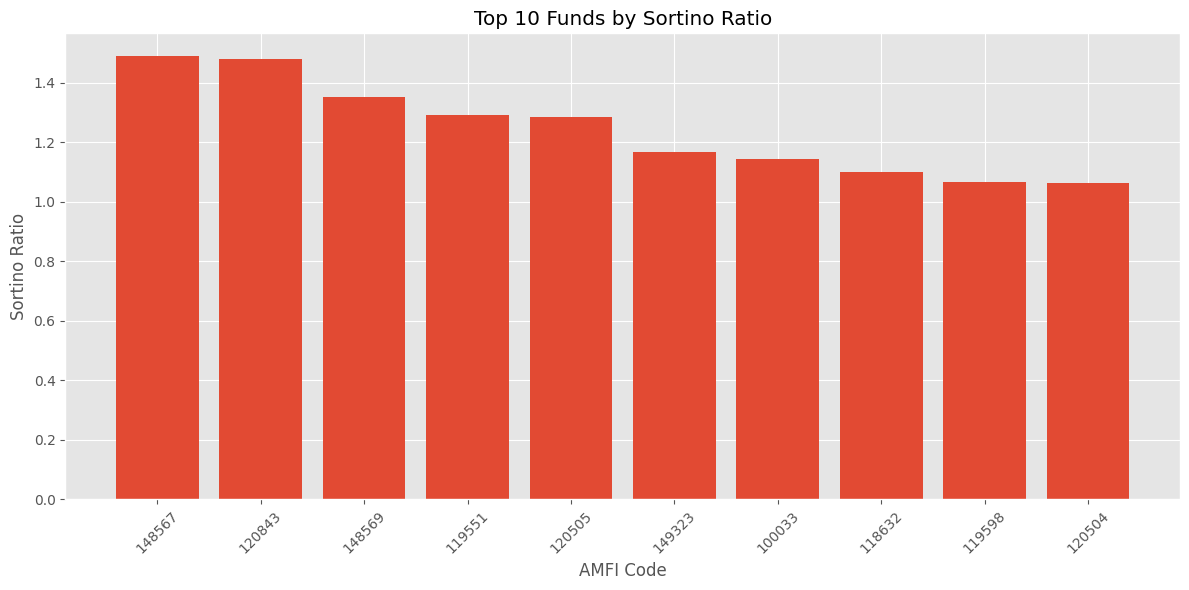

In [29]:
top10 = sortino_df.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["Sortino_Ratio"]
)

plt.title("Top 10 Funds by Sortino Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sortino Ratio")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Step 10: Alpha and Beta Analysis

Alpha and Beta are calculated to evaluate the relationship between each mutual fund and the Nifty 100 benchmark.

- **Beta** measures the sensitivity of a fund's returns relative to the benchmark.
- **Alpha** measures the excess annualized return generated by the fund after accounting for market movements.

The analysis uses Ordinary Least Squares (OLS) Linear Regression (`scipy.stats.linregress`).

**Formula**

- Beta = Regression Slope
- Alpha = Regression Intercept × 252

In [30]:
benchmark = pd.read_csv("../data/processed/benchmark_indices_cleaned.csv")

In [31]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [32]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [33]:
benchmark.info()

<class 'pandas.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   str    
 1   index_name   8050 non-null   str    
 2   close_value  8050 non-null   float64
dtypes: float64(1), str(2)
memory usage: 188.8 KB


### Explore Available Benchmark Indices

The benchmark dataset is inspected to identify the available market indices before selecting the Nifty 100 benchmark for comparison.

In [34]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

### Step 10.4: Prepare the NIFTY100 Benchmark

The benchmark dataset is filtered to retain only the NIFTY100 index. Daily benchmark returns are then calculated using percentage change in closing values.

In [35]:

nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()


nifty100["date"] = pd.to_datetime(nifty100["date"])

nifty100 = nifty100.sort_values("date")


nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


### Step 10.5: Calculate Alpha and Beta

Each mutual fund is merged with the NIFTY100 benchmark based on the trading date. Ordinary Least Squares (OLS) regression is then applied using `scipy.stats.linregress`.

- **Beta** is the regression slope.
- **Alpha** is the regression intercept annualized by multiplying by 252 trading days.

In [36]:
alpha_beta_results = []

for fund, group in nav.groupby("amfi_code"):

    
    merged = pd.merge(
        group,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    
    if len(merged) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta_results.append({
        "amfi_code": fund,
        "Alpha": intercept * 252,
        "Beta": slope,
        "R_Squared": r_value ** 2
    })

In [37]:
alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df.head()

,amfi_code,Alpha,Beta,R_Squared
0,100016,0.037476,-0.058268,0.002665
1,100025,0.042818,0.001158,0.000015
2,100033,0.271954,0.005104,0.000012
3,101206,0.213998,0.021086,0.000348
4,101207,0.108971,-0.065289,0.001064


### Step 10.6: Rank Funds by Alpha

Funds are ranked based on annualized Alpha. A higher Alpha indicates better performance relative to the benchmark after adjusting for market risk.

In [38]:
alpha_beta_df = alpha_beta_df.sort_values(
    by="Alpha",
    ascending=False
)

alpha_beta_df.reset_index(drop=True, inplace=True)

alpha_beta_df["Alpha_Rank"] = alpha_beta_df.index + 1

alpha_beta_df.head(10)

,amfi_code,Alpha,Beta,R_Squared,Alpha_Rank
0,119598,0.303370,-0.023196,1.414258e-04,1
1,149324,0.300579,0.011455,3.532991e-05,2
2,120505,0.292636,0.000549,1.345534e-07,3
3,148569,0.282704,0.018134,1.748889e-04,4
4,120843,0.273305,-0.022830,3.430543e-04,5
5,100033,0.271954,0.005104,1.206652e-05,6
6,148567,0.269838,0.023684,4.625437e-04,7
7,149323,0.265986,-0.002523,3.357978e-06,8
8,119094,0.260767,-0.066265,1.936879e-03,9
9,119551,0.232010,-0.031751,8.869789e-04,10


### Step 10.7: Save Alpha and Beta Results

The Alpha and Beta analysis results are exported as a CSV file for further use in the mutual fund scorecard.

In [39]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("Alpha & Beta analysis saved successfully!")

Alpha & Beta analysis saved successfully!


## Step 11: Maximum Drawdown Analysis

Maximum Drawdown (MDD) measures the largest percentage decline from a fund's historical peak NAV to its subsequent lowest point before a new peak is achieved.

It is one of the most important downside risk metrics used by investors to assess the worst historical loss experienced by a mutual fund.

In [40]:
drawdown_results = []

for fund, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    
    group["Running_Max"] = group["nav"].cummax()

 
    group["Drawdown"] = (
        group["nav"] /
        group["Running_Max"]
    ) - 1

    
    max_drawdown = group["Drawdown"].min()

    worst_row = group.loc[group["Drawdown"].idxmin()]

    drawdown_results.append({
        "amfi_code": fund,
        "Maximum_Drawdown": max_drawdown,
        "Worst_Date": worst_row["date"]
    })

In [41]:
drawdown_df = pd.DataFrame(drawdown_results)

drawdown_df.head()

,amfi_code,Maximum_Drawdown,Worst_Date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [42]:
drawdown_df = drawdown_df.sort_values(
    by="Maximum_Drawdown",
    ascending=False
)

drawdown_df.reset_index(drop=True, inplace=True)

drawdown_df["Drawdown_Rank"] = drawdown_df.index + 1

drawdown_df.head(10)

,amfi_code,Maximum_Drawdown,Worst_Date,Drawdown_Rank
0,120507,-0.000977,2025-10-20,1
1,120844,-0.001163,2024-04-30,2
2,101208,-0.001622,2023-09-12,3
3,100025,-0.043083,2023-07-28,4
4,119120,-0.043287,2025-04-01,5
5,118636,-0.083164,2024-02-09,6
6,102885,-0.108599,2022-03-29,7
7,148567,-0.112657,2023-10-20,8
8,101206,-0.112916,2023-07-05,9
9,118635,-0.116506,2022-06-09,10


In [43]:
drawdown_df.to_csv(
    "../reports/maximum_drawdown.csv",
    index=False
)

print("Maximum Drawdown analysis saved successfully!")

Maximum Drawdown analysis saved successfully!


### Top 10 Funds with Lowest Maximum Drawdown

The following chart displays the funds that experienced the smallest historical drawdowns, indicating relatively better downside protection.

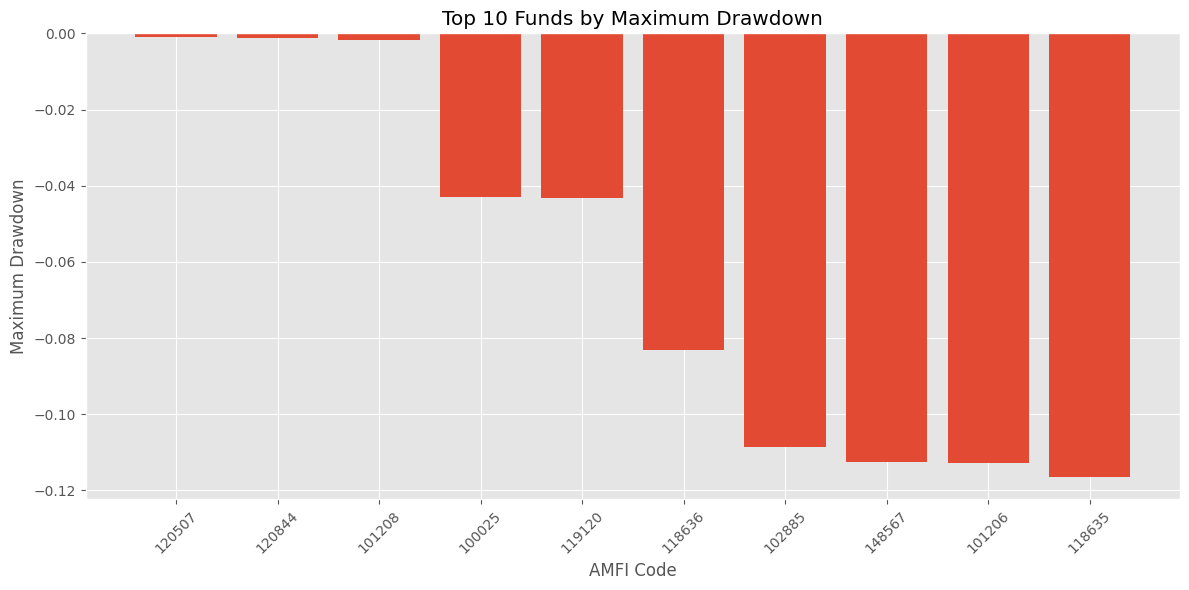

In [44]:
top10 = drawdown_df.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["Maximum_Drawdown"]
)

plt.title("Top 10 Funds by Maximum Drawdown")
plt.xlabel("AMFI Code")
plt.ylabel("Maximum Drawdown")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Step 12: Fund Scorecard

A composite fund score is created by combining multiple performance metrics into a single score ranging from 0 to 100.

Weightage:

- 30% → 3-Year CAGR
- 25% → Sharpe Ratio
- 20% → Alpha
- 15% → Expense Ratio (Lower is Better)
- 10% → Maximum Drawdown (Lower is Better)

The final score enables an overall comparison of all mutual funds.

In [45]:
fund_master = pd.read_csv("../data/processed/fund_master_cleaned.csv")

fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

In [46]:
scheme_perf = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

scheme_perf.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade', 'return_anomaly_flag',
       'expense_ratio_valid'],
      dtype='str')

### Step 12.1: Prepare Ranking Metrics

The performance metrics are ranked individually before combining them into a weighted composite score.

For metrics where a higher value indicates better performance (CAGR, Sharpe Ratio, Alpha), ranks are assigned in descending order.

For metrics where a lower value indicates better performance (Expense Ratio and Maximum Drawdown), inverse ranking is applied.

In [47]:
fund_master = pd.read_csv("../data/processed/fund_master_cleaned.csv")

expense_df = fund_master[
    ["amfi_code", "expense_ratio_pct"]
].copy()

expense_df.head()

,amfi_code,expense_ratio_pct
0,119551,1.54
1,119552,0.66
2,119598,1.43
3,119599,0.72
4,119120,0.77


In [48]:
scorecard = cagr_df.merge(
    sharpe_df[["amfi_code", "Sharpe_Ratio"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "Alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df[["amfi_code", "Maximum_Drawdown"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    expense_df,
    on="amfi_code"
)

scorecard.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Ratio,Alpha,Maximum_Drawdown,expense_ratio_pct
0,119094,0.222611,0.351118,0.244453,0.730547,0.260767,-0.209609,1.38
1,148567,0.203607,0.340009,0.267993,1.068224,0.269838,-0.112657,1.46
2,120504,0.130643,0.324874,0.202340,0.714682,0.211948,-0.125883,0.80
3,100033,0.532324,0.324425,0.260741,0.808268,0.271954,-0.162172,1.38
4,120505,0.296047,0.317775,0.283768,0.883256,0.292636,-0.181885,1.36


### Step 12.3: Rank Individual Performance Metrics

Each performance metric is converted into a ranking so that funds can be compared consistently before calculating the composite score.

In [49]:
scorecard["Return_Rank"] = scorecard["CAGR_3Y"].rank(
    ascending=False,
    method="min"
)

scorecard["Sharpe_Rank"] = scorecard["Sharpe_Ratio"].rank(
    ascending=False,
    method="min"
)

scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(
    ascending=False,
    method="min"
)


scorecard["Expense_Rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True,
    method="min"
)

scorecard["Drawdown_Rank"] = scorecard["Maximum_Drawdown"].rank(
    ascending=False,
    method="min"
)

### Step 12.4: Compute Composite Fund Score

The final score is calculated using the predefined weighted ranking system.

Higher scores indicate stronger overall performance after considering returns, risk-adjusted performance, expenses, and downside risk.

In [50]:
max_rank = len(scorecard)

scorecard["Fund_Score"] = (
    (max_rank - scorecard["Return_Rank"] + 1) * 0.30 +
    (max_rank - scorecard["Sharpe_Rank"] + 1) * 0.25 +
    (max_rank - scorecard["Alpha_Rank"] + 1) * 0.20 +
    (max_rank - scorecard["Expense_Rank"] + 1) * 0.15 +
    (max_rank - scorecard["Drawdown_Rank"] + 1) * 0.10
)


scorecard["Fund_Score"] = (
    scorecard["Fund_Score"] /
    scorecard["Fund_Score"].max()
) * 100

In [51]:
scorecard = scorecard.sort_values(
    by="Fund_Score",
    ascending=False
)

scorecard.reset_index(drop=True, inplace=True)

scorecard["Overall_Rank"] = scorecard.index + 1

scorecard.head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Ratio,Alpha,Maximum_Drawdown,expense_ratio_pct,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Fund_Score,Overall_Rank
0,148567,0.203607,0.340009,0.267993,1.068224,0.269838,-0.112657,1.46,2.0,1.0,7.0,23.0,8.0,100.000000,1
1,120505,0.296047,0.317775,0.283768,0.883256,0.292636,-0.181885,1.36,5.0,4.0,3.0,15.0,25.0,96.086957,2
2,120843,0.266571,0.295828,0.267425,0.965561,0.273305,-0.129740,1.45,7.0,2.0,5.0,22.0,13.0,95.072464,3
3,100033,0.532324,0.324425,0.260741,0.808268,0.271954,-0.162172,1.38,4.0,7.0,6.0,16.0,20.0,94.057971,4
4,120504,0.130643,0.324874,0.202340,0.714682,0.211948,-0.125883,0.80,3.0,11.0,13.0,12.0,12.0,92.028986,5
5,119094,0.222611,0.351118,0.244453,0.730547,0.260767,-0.209609,1.38,1.0,9.0,9.0,16.0,28.0,91.159420,6
6,119551,0.604373,0.304565,0.223849,0.860977,0.232010,-0.150124,1.54,6.0,5.0,10.0,30.0,17.0,86.231884,7
7,148569,0.397518,0.291789,0.276299,0.919047,0.282704,-0.163967,1.60,8.0,3.0,4.0,36.0,21.0,85.652174,8
8,119598,0.827761,0.266699,0.280332,0.711690,0.303370,-0.287060,1.43,12.0,13.0,1.0,21.0,36.0,78.840580,9
9,101206,0.479241,0.289677,0.204427,0.717409,0.213998,-0.112916,1.60,9.0,10.0,12.0,36.0,9.0,78.550725,10


In [52]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard saved successfully!")

Fund Scorecard saved successfully!


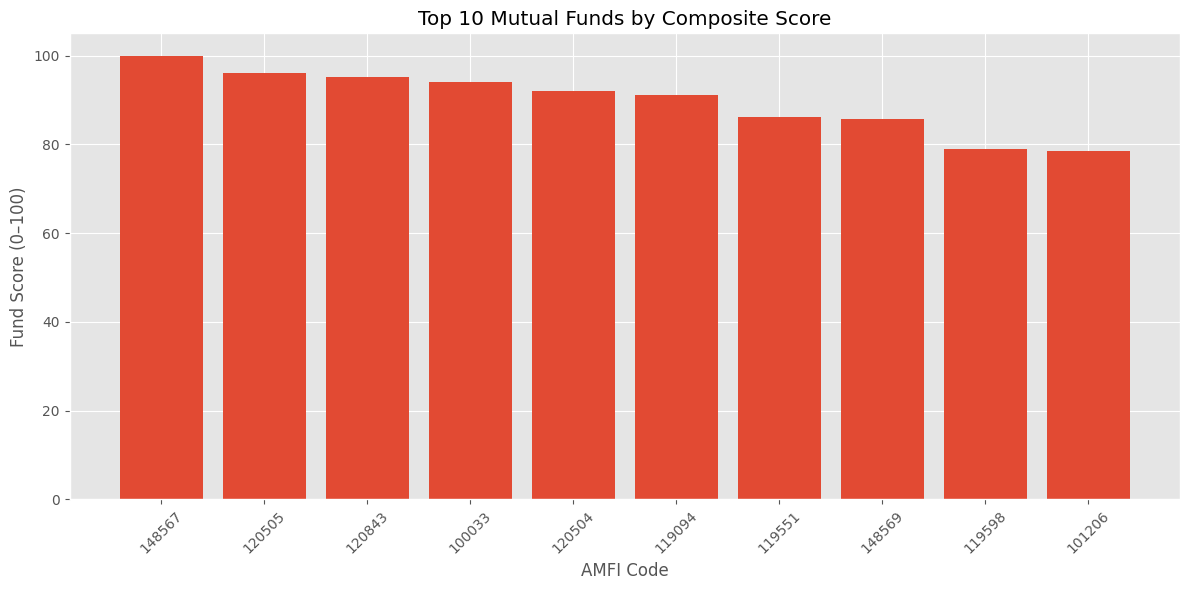

In [53]:
top10 = scorecard.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["Fund_Score"]
)

plt.title("Top 10 Mutual Funds by Composite Score")
plt.xlabel("AMFI Code")
plt.ylabel("Fund Score (0–100)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Step 13: Benchmark Comparison

The top five mutual funds are compared against the NIFTY50 and NIFTY100 benchmark indices over the last three years.

The analysis includes:

- NAV growth comparison
- Benchmark performance comparison
- Tracking Error calculation

Tracking Error measures how closely a fund follows its benchmark.

Formula:

Tracking Error = Standard Deviation(Fund Return − Benchmark Return) × √252

In [54]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

In [55]:
end_date = nav["date"].max()

start_date = end_date - pd.DateOffset(years=3)

nav_3yr = nav[
    nav["date"] >= start_date
]

nifty50 = nifty50[
    nifty50["date"] >= start_date
]

nifty100 = nifty100[
    nifty100["date"] >= start_date
]

In [56]:
top5 = scorecard.head(5)["amfi_code"].tolist()

top5

[148567, 120505, 120843, 100033, 120504]

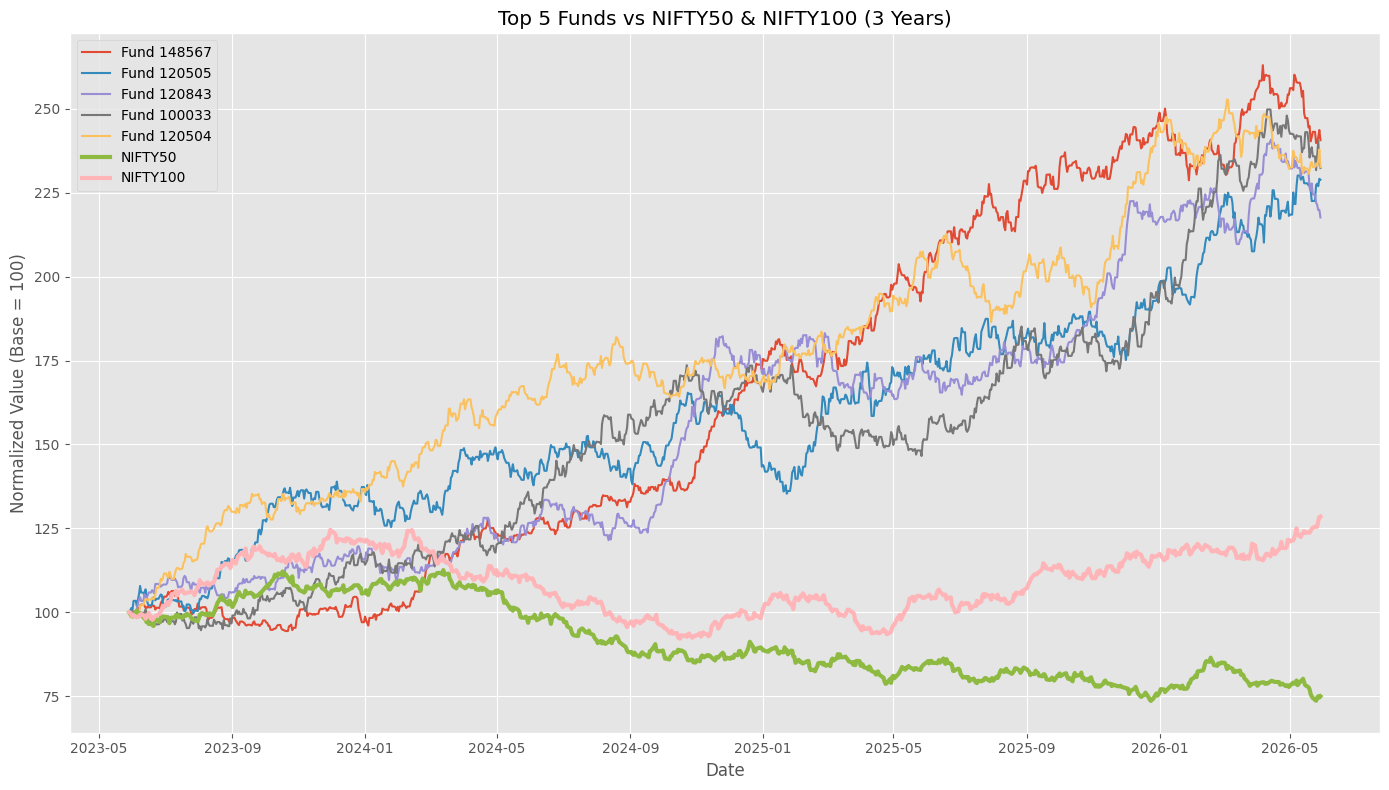

In [57]:
plt.figure(figsize=(14,8))


for fund in top5:

    temp = nav_3yr[
        nav_3yr["amfi_code"] == fund
    ].copy()

    temp = temp.sort_values("date")

    temp["Normalized"] = (
        temp["nav"] /
        temp["nav"].iloc[0]
    ) * 100

    plt.plot(
        temp["date"],
        temp["Normalized"],
        label=f"Fund {fund}"
    )


nifty50 = nifty50.sort_values("date")
nifty50["Normalized"] = (
    nifty50["close_value"] /
    nifty50["close_value"].iloc[0]
) * 100

plt.plot(
    nifty50["date"],
    nifty50["Normalized"],
    linewidth=3,
    label="NIFTY50"
)


nifty100 = nifty100.sort_values("date")
nifty100["Normalized"] = (
    nifty100["close_value"] /
    nifty100["close_value"].iloc[0]
) * 100

plt.plot(
    nifty100["date"],
    nifty100["Normalized"],
    linewidth=3,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100 (3 Years)")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig("../images/benchmark_comparison.png")

plt.show()

In [58]:
tracking_results = []


nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

for fund in top5:

    temp = nav_3yr[
        nav_3yr["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        temp,
        nifty100[["date", "benchmark_return"]],
        on="date"
    ).dropna()

    tracking_error = (
        (merged["daily_return"] - merged["benchmark_return"]).std()
        * np.sqrt(252)
    )

    tracking_results.append({
        "amfi_code": fund,
        "Tracking_Error": tracking_error
    })

tracking_df = pd.DataFrame(tracking_results)

tracking_df

,amfi_code,Tracking_Error
0,148567,0.187974
1,120505,0.232661
2,120843,0.206540
3,100033,0.224976
4,120504,0.187299


In [59]:
tracking_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("Tracking Error saved successfully!")

Tracking Error saved successfully!
